# ___Summary of hOUwie model fits___
-------------------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.6.1 (2026-06-24 ucrt)"


In [2]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("corHMM")
    library("OUwie")
    library("lattice")
    library("ggplot2")
    library("reshape2")
    library("ggpubr")
})

# source("../houwie_patches.R")

In [3]:
packageVersion("OUwie")

[1] '3.0.3'

In [4]:
packageVersion("corHMM")

[1] '2.8'

In [5]:
# the OUMA and OUMVA model issues have been fixed in OUwie versions 3.00 and up, see the below page for details
# https://thej022214.github.io/OUwie/articles/calculationUpdate.html

In [3]:
#--------------------------
# helper functions
#--------------------------

STATE_COLOURS <- c(AM = "#E7BC0C", EcM = "#23B9AF", ErM = "#6B6CF2", NM = "#11E823", NMAM = "#2D2E30", EcMAM = "#E71A23")

compare_houwie_groups <- function(gp_cd, gp_cid){
    tab <- cbind(OUwie::getModelTable(gp_cd, type = "AICc")[, c("AICc", "dAICc")], OUwie::getModelTable(gp_cid, type = "AICc")[, c("AICc", "dAICc")])
    names(tab) <- c("cd_AICc", "cd_dAICc", "cid_AICc", "cid_dAICc")
    tab
}

read_all_rds <- function(dirpath, cd, strip, rm_underscores = TRUE) {
    # dirpath = path to the directory containing the .Rds files
    # cd = character dependent or independent models, these are expected to contain "CD" or "CID" in their names
    # strip = the regex pattern to strip out of the file names when naming objects, can be a plain string as well
    # rm_underscores - strip all the underscores in the object name

    fnames <- list.files(dirpath) # all the files in the specified dir
    if(cd) fnames <- fnames[grep(pattern = "CD", fnames)]
    else fnames <- fnames[grep(pattern = "CID", fnames)] # cherry pick CD or CID models, given their names contain "CD" or "CID" to distinguish them
    # print(fnames)

    paths <- paste0(dirpath, fnames) # relative paths for all the Rds files
    stopifnot(length(fnames)==length(paths))

    # remove the unnecessary parts of the file names to create the model names and also remove all the underscores
    mnames <- fnames |> gsub(pattern = ".Rds", replacement = '') |> gsub(pattern = strip, replacement = '') |> gsub(pattern = ifelse(rm_underscores, '_', ''), replacement = '')
    stopifnot(length(fnames)==length(mnames))
    stopifnot(length(paths)==length(mnames))

    models <- list()
    for (i in seq_along(mnames)) models[[mnames[i]]] <- readRDS(file = paths[i])
    stopifnot(length(models)==length(mnames))

    models
}


convergence_failures <- function(models, strip='', threshold_diff_aicc=1e10){
    model_table <- OUwie::getModelTable(models, type = "AICc") # model table from the models
    model_names <- row.names(model_table)
    model_names <- gsub(pattern = strip, replacement = '', x = model_names) # strip off the specified pattern from the names
    
    aiccs <- model_table[, "AICc"] # this becomes a hard requirement of the function, that the input dataframe needs to have a column named "AICc"
    # so the criteria is that the absoulte difference between the AICc of a given model and the highest AICc (worst fit) shouldn't exceed 1e5, else it's considered a convergence failure
    model_names[abs(aiccs - max(aiccs)) >= threshold_diff_aicc]  # with an option provided to pass in a custom difference threshold
}


plot_model_averages <- function(data){
    # the data argument is expected to be the untouched output of the OUwie::getModelAvgParams() function
    stopifnot(is.data.frame(data))
    
    options(repr.plot.width = 15, repr.plot.height = 15)
    par(mfrow = c(2, 2), mar = c(3, 4, 0, 0), mgp = c(2.25, 0.75, 0))

    boxplot(formula = rates ~ tip_state, data = data, xlab = NULL, ylab = "Rates", border = STATE_COLOURS, col = "white")
    boxplot(formula = alpha ~ tip_state, data = data, xlab = NULL, ylab = expression(alpha), border = STATE_COLOURS, col = "white")
    boxplot(formula = sigma.sq ~ tip_state, data = data, xlab = NULL, ylab = expression(sigma^2), border = STATE_COLOURS, col = "white")
    boxplot(formula = theta ~ tip_state, data = data, xlab = NULL, ylab = expression(theta), border = STATE_COLOURS, col = "white")
}

In [8]:
# find out the AIC and AICc of all the models

# OUwie::getModelAvgParams()
# type - one of AIC, BIC, or AICc for use during evaluation of relative model fit.
# AICc (small sample size corrected AIC) is the best option for datasets with a few number of species.
# force - a boolean indicating whether to force potentially failed model fits to be included in the model averaging.

# look up to see what the BIC stuff is about https://www.rdocumentation.org/packages/AICcmodavg/versions/2.3-4/topics/bictabCustom
# AIC vs BIC https://fiveable.me/bayesian-statistics/unit-11/bayesian-information-criterion/study-guide/o3iS2biLgz7mcyuv

# ___Parameter Tuning___
---------------------

In [9]:
# inspect the old hOUwie fits to optimize future fits

models_cd <- read_all_rds("../../data/chapter2/rdata/parallel/rd_1301_100sims/", cd = TRUE, strip = "_F00679_CD")
models_cid <- read_all_rds("../../data/chapter2/rdata/parallel/rd_1301_100sims/", cd = FALSE, strip = "_F00679_CID")

In [12]:
model <- readRDS("../../data/chapter2/rdata/parallel/rd_1301_100sims/SYMOUMA_F00679_CID.Rds")

# https://github.com/thej022214/OUwie/blob/master/R/hOUwie.R#L110
setNames(model$ub_continuous_model, nm = c("alpha", "sigma", "theta")) # bounds of the continuous trait are in the following order - c(lb.alpha,lb.sigma,lb.optim)

alpha       sigma       theta 
  0.1729462   0.1729462 499.9899950

In [13]:
model$ub_discrete_model

[1] 24.95087

In [14]:
model$lb_continuous_model

[1] 0.0000000001 0.0000000001 4.7450490827

In [15]:
model$lb_discrete_model

[1] 2.495087e-07

In [16]:
model$solution.cont

,(1A),(2A),(3A),(4A),(5A),(6A),(1B),(2B),(3B),(4B),(5B),(6B)
alpha,0.009615693,0.009615693,0.009615693,0.009615693,0.009615693,0.009615693,2.229048e-05,2.229048e-05,2.229048e-05,2.229048e-05,2.229048e-05,2.229048e-05
sigma2,0.172946239,0.172946239,0.172946239,0.172946239,0.172946239,0.172946239,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01
theta,-45.254950917,-45.254950917,-45.254950917,-45.254950917,-45.254950917,-45.254950917,1.079381e+02,1.079381e+02,1.079381e+02,1.079381e+02,1.079381e+02,1.079381e+02


In [18]:
apply(model$solution.cont, MARGIN = 1, FUN = min)

alpha        sigma2         theta 
 2.229048e-05  1.729462e-01 -4.525495e+01

In [109]:
# upper and lower bounds of discrete and continuous models
# everything looks identical (these are defaults?? - not model estimated parameters!!!)

mapply(models_cd, FUN = function(x) list(UBC = x$ub_continuous_model, LBC = x$lb_continuous_model, UBD = x$ub_discrete_model, LBD = x$lb_discrete_model)) |> t() |> as.data.frame()

,UBC,LBC,UBD,LBD
,<named list>,<named list>,<named list>,<named list>
ARDOUM,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
ARDOUMA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
ARDOUMV,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
ARDOUMVA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUM,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUMA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUMV,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUMVA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
SYMOUM,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07


In [81]:
mapply(models_cid, FUN = function(x) list(UBC = x$ub_continuous_model, LBC = x$lb_continuous_model, UBD = x$ub_discrete_model, LBD = x$lb_discrete_model)) |> t() |> as.data.frame()

,UBC,LBC,UBD,LBD
,<named list>,<named list>,<named list>,<named list>
ARDOUM,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
ARDOUMA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
ARDOUMV,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
ARDOUMVA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUM,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUMA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUMV,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUMVA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
SYMOUM,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07


In [89]:
# transition rates

mapply(models_cd, FUN = function(x) list(dmax = max(x$solution.disc, na.rm = TRUE), dmin = min(x$solution.disc, na.rm = TRUE))) |> t() |> as.data.frame()

,dmax,dmin
,<named list>,<named list>
ARDOUM,0.006338935,1.373761e-06
ARDOUMA,0.0002656235,8.090315e-06
ARDOUMV,0.004001858,1.182816e-05
ARDOUMVA,0.0002656235,8.66839e-06
EROUM,0.0002238004,0.0002238004
EROUMA,6.801639,6.801639
EROUMV,0.0002022754,0.0002022754
EROUMVA,0.008399754,0.008399754
SYMOUM,0.0007361478,4.140943e-07


In [92]:
mapply(models_cid, FUN = function(x) list(dmax = max(x$solution.disc, na.rm = TRUE), dmin = min(x$solution.disc, na.rm = TRUE))) |> t() |> as.data.frame()

,dmax,dmin
,<named list>,<named list>
ARDOUM,0.0003752032,0.0001675971
ARDOUMA,0.0002656235,4.723529e-05
ARDOUMV,0.0002656235,0.0002656235
ARDOUMVA,0.02656235,0.0001214134
EROUM,0.0003812546,5.16566e-05
EROUMA,0.01278417,2.495087e-07
EROUMV,0.0007774337,8.399754e-05
EROUMVA,0.006779943,0.0002656235
SYMOUM,0.000336724,5.972368e-06


In [1]:
# for continuous models the sequence is c(alpha, sigma, theta)

In [24]:
# CD fits - continuous model params - maxes

mapply(models_cd, FUN = function(x) apply(x$solution.cont, MARGIN = 1, FUN = max, na.rm = TRUE)) # this returns the max of each params for different states within each fits

,ARDOUM,ARDOUMA,ARDOUMV,ARDOUMVA,EROUM,EROUMA,EROUMV,EROUMVA,SYMOUM,SYMOUMA,SYMOUMV,SYMOUMVA
alpha,2.738273e-07,0.02175001,5.848399e-09,0.02175001,1.047976e-10,0.04528611,1.060156e-10,0.01961547,1.476953e-10,2.118098e-03,1.399549e-10,0.06060018
sigma2,1.729462e-01,0.17294624,1.729462e-01,0.05469040,1.729462e-01,0.17294624,1.729462e-01,0.17294624,1.729462e-01,1.729462e-01,1.729462e-01,0.17294624
theta,4.499900e+02,-0.91082740,4.499900e+02,0.98686036,1.940909e+02,3.18866445,3.251291e+02,107.27723423,1.074415e+02,1.559061e+02,1.421200e+02,125.05260777


In [27]:
mapply(models_cd, FUN = function(x) apply(x$solution.cont, MARGIN = 1, FUN = max, na.rm = TRUE)) |> apply(FUN = max, MARGIN = 1) # max across all the fits

alpha       sigma2        theta 
  0.06060018   0.17294624 449.98999500

In [28]:
mapply(models_cd, FUN = function(x) apply(x$solution.cont, MARGIN = 1, FUN = min, na.rm = TRUE)) |> apply(FUN = min, MARGIN = 1) # min across all the fits

alpha        sigma2         theta 
 1.000000e-10  1.355719e-06 -4.525495e+01

In [30]:
# CID fits

mapply(models_cid, FUN = function(x) apply(x$solution.cont, MARGIN = 1, FUN = max, na.rm = TRUE))

,ARDOUM,ARDOUMA,ARDOUMV,ARDOUMVA,EROUM,EROUMA,EROUMV,EROUMVA,SYMOUM,SYMOUMA,SYMOUMV,SYMOUMVA
alpha,7.289750e-05,0.01457781,5.469040e-08,0.02059171,5.442531e-05,5.469040e-05,5.469040e-05,5.472754e-05,1.766810e-05,9.615693e-03,7.100862e-09,9.725482e-03
sigma2,1.729462e-01,0.17294624,1.729462e-01,0.17294624,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01
theta,1.126031e+02,98.57260218,1.079381e+02,107.93811043,1.574389e+02,1.645572e+02,1.205584e+02,1.051561e+02,4.499900e+02,1.079381e+02,1.236215e+02,1.079381e+02


In [31]:
mapply(models_cid, FUN = function(x) apply(x$solution.cont, MARGIN = 1, FUN = max, na.rm = TRUE)) |> apply(FUN = max, MARGIN = 1) # max across all the fits

alpha       sigma2        theta 
  0.02059171   0.17294624 449.98999500

In [32]:
mapply(models_cid, FUN = function(x) apply(x$solution.cont, MARGIN = 1, FUN = min, na.rm = TRUE)) |> apply(FUN = min, MARGIN = 1) # min across all the fits

alpha        sigma2         theta 
 7.100862e-09  7.293082e-04 -4.525495e+01

# ___1301 species, 6 states and FRED 4.0 post `houwie-update`___
---------------------------

# $t_{1/2} = \frac{log(2)}{\alpha}$
	
# $V_{stationary} = \frac{\sigma^2}{2 \alpha}$

In [ ]:
# https://github.com/thej022214/OUwie/tree/houwie-update

In [17]:
STATE_COLOURS <- c(AM = "#E7BC0C", EcM = "#23B9AF", ErM = "#6B6CF2", NM = "#11E823", NMAM = "#2D2E30", EcMAM = "#E71A23")

## ___RD___
-------------------------

In [18]:
rd_new_cd <- read_all_rds("../../data/chapter2/rdata/hie-general/houwie-update/RD/", cd = TRUE, strip = "_F00679_CD_100")
rd_new_cid <- read_all_rds("../../data/chapter2/rdata/hie-general/houwie-update/RD/", cd = FALSE, strip = "_F00679_CID_100")

In [10]:
OUwie::getModelTable(rd_new_cd, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,38,-1010.270,-204.2927,-798.6367,2098.888,34.624896,2.910347e-08
ARDOUMA,43,-1005.471,-205.1237,-793.4270,2099.952,35.689324,1.709256e-08
ARDOUMV,43,-1007.558,-204.5516,-797.7127,2104.127,39.864290,2.119458e-09
ARDOUMVA,48,-1003.788,-204.8559,-792.8556,2107.334,43.071096,4.264574e-10
EROUM,9,-1028.576,-223.7613,-795.1226,2075.291,11.027671,3.872728e-03
EROUMA,14,-1025.683,-224.2258,-793.6264,2079.693,15.430454,4.285138e-04
EROUMV,14,-1024.862,-224.4261,-792.2893,2078.052,13.788505,9.738891e-04
EROUMVA,19,-1012.835,-224.2323,-780.6175,2064.263,0.000000,9.608274e-01
SYMOUM,23,-1012.714,-207.8091,-796.3740,2072.293,8.030229,1.733418e-02


In [11]:
OUwie::getModelTable(rd_new_cid, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,66,-996.2278,-250.5429,-753.3318,2131.622,178.74853,1.531963e-39
ARDOUMA,67,-1020.9135,-487.8563,-725.0186,2183.217,230.34315,9.585612e-51
ARDOUMV,67,-1024.9819,-323.0189,-716.3393,2191.354,238.48002,1.639537e-52
ARDOUMVA,68,-1017.9832,-226.4809,-777.8426,2179.583,226.70942,5.897594e-50
EROUM,8,-981.6118,-367.8199,-684.4236,1979.335,26.46103,1.794984e-06
EROUMA,9,-1012.3366,-366.6254,-711.4832,2042.813,89.93860,2.951755e-20
EROUMV,9,-989.5762,-526.7730,-683.9435,1997.292,44.41784,2.263536e-10
EROUMVA,10,-1000.9691,-376.8922,-718.3404,2022.109,69.23474,9.244146e-16
SYMOUM,36,-970.5243,-255.5475,-696.4220,2015.156,62.28230,2.989298e-14


In [19]:
# model averages for RD

rd_avgs_cd <- OUwie::getModelAvgParams(rd_new_cd, type = "AICc", force = FALSE)
rd_avgs_cid <- OUwie::getModelAvgParams(rd_new_cid, type = "AICc", force = FALSE)

In [122]:
# incorporate the colours as another column
# rd_avgs_cid$colour <- STATE_COLOURS[rd_avgs_cid$tip_state] |> as.vector()

In [124]:
aggregate(sigma.sq ~ tip_state, data = rd_avgs_cid, FUN = length)

tip_state,sigma.sq
<chr>,<int>
AM,1097
EcM,121
EcMAM,20
ErM,9
NM,16
NMAM,38


In [127]:
# https://www.datanovia.com/learn/data-visualization/ggplot2/error-bars

options(repr.plot.width = 10, repr.plot.height = 10)

# summary table
summtab <- data.frame(
    tip.state = aggregate(sigma.sq ~ tip_state, data = rd_avgs_cid, FUN = mean)$tip_state, # mycorrhizal state
    n = aggregate(sigma.sq ~ tip_state, data = rd_avgs_cid, FUN = length)$sigma.sq, # n
    m = aggregate(sigma.sq ~ tip_state, data = rd_avgs_cid, FUN = mean)$sigma.sq, # mean
    err = aggregate(sigma.sq ~ tip_state, data = rd_avgs_cid, FUN = function(s) { sd(s) / sqrt(length(s)) })$sigma.sq # stderr
)

p <- ggplot2::ggplot(aes(x = tip_state, y = sigma.sq), data = rd_avgs_cid) + 
     theme_bw() +
     geom_point(pch = 21, size = 3.5, show.legend = FALSE, fill = "white", colour = "black") + # the raw data points
     stat_summary(fun = "mean", geom = "point", size = 3.5, fill = "grey", colour = "black", pch = 21) + # means as points
     geom_errorbar(aes(ymin = m - err, ymax = m + err, x = tip.state, y = m), data = summtab, inherit.aes = FALSE, width = 0.3) + # standard error bars
     geom_text(aes(y = m, x = tip.state, label = paste0("n=", n)), hjust = -0.5, vjust = 1.5, data = summtab, inherit.aes = FALSE, size = 4) + # number of obs per group
     ylab(expression(sigma[RD]^2)) +
     theme(axis.title.y = element_text(size = 20, vjust = 2.25), axis.text = element_text(size = 15)) + 
     xlab(NULL)

ggplot2::ggsave(filename = "../../plots/sigmasq_CID_RD.png", plot = p, device = "png", width = 10, height = 10, units = "in", dpi = 500)

## ___SRL___
-----------------

In [20]:
srl_new_cd <- read_all_rds("../../data/chapter2/rdata/hie-general/houwie-update/SRL/", cd = TRUE, strip = "_F00727_CD_100")
srl_new_cid <- read_all_rds("../../data/chapter2/rdata/hie-general/houwie-update/SRL/", cd = FALSE, strip = "_F00727_CID_100")

In [10]:
OUwie::getModelTable(srl_new_cd, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,38,-2289.800,-204.7249,-2077.563,4657.949,23.5624555,2.983142e-06
ARDOUMA,43,-2284.300,-205.0339,-2070.401,4657.611,23.2248490,3.531703e-06
ARDOUMV,43,-2285.183,-204.9484,-2076.012,4659.377,24.9905889,1.460692e-06
ARDOUMVA,48,-2284.385,-205.3292,-2072.013,4668.528,34.1416139,1.504662e-08
EROUM,9,-2309.949,-223.9789,-2079.684,4638.037,3.6512844,6.285354e-02
EROUMA,14,-2305.174,-224.3805,-2074.767,4638.675,4.2893312,4.568563e-02
EROUMV,14,-2305.945,-224.4289,-2075.341,4640.217,5.8312388,2.113288e-02
EROUMVA,19,-2301.900,-224.1698,-2071.315,4642.393,8.0064163,7.122376e-03
SYMOUM,23,-2294.020,-207.1925,-2079.124,4634.904,0.5182975,3.010574e-01


In [11]:
OUwie::getModelTable(srl_new_cid, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,66,-2747.992,-231.0784,-2539.280,5635.152,1063.44479,1.190962e-231
ARDOUMA,67,-2337.879,-418.9557,-2066.624,4817.148,245.44151,5.047232e-54
ARDOUMV,67,-2369.040,-352.9374,-2128.832,4879.470,307.76324,1.479319e-67
ARDOUMVA,68,-2346.543,-248.1520,-2077.249,4836.704,264.99686,2.861952e-58
EROUM,8,-2339.338,-224.1813,-2109.070,4694.788,123.08090,1.876389e-27
EROUMA,9,-2328.390,-223.7516,-2098.097,4674.920,103.21332,3.868230e-23
EROUMV,9,-2327.469,-559.8723,-1993.739,4673.078,101.37120,9.716792e-23
EROUMVA,10,-2328.512,-223.6507,-2098.217,4677.195,105.48769,1.240618e-23
SYMOUM,36,-2309.256,-235.3004,-2083.201,4692.620,120.91262,5.548265e-27


In [21]:
srl_avgs_cd <- OUwie::getModelAvgParams(srl_new_cd, type = "AICc", force = FALSE)
srl_avgs_cid <- OUwie::getModelAvgParams(srl_new_cid, type = "AICc", force = FALSE)

In [134]:
options(repr.plot.width = 10, repr.plot.height = 10)

# summary table
summtab <- data.frame(
    tip.state = aggregate(sigma.sq ~ tip_state, data = srl_avgs_cid, FUN = mean)$tip_state,
    n = aggregate(sigma.sq ~ tip_state, data = srl_avgs_cid, FUN = length)$sigma.sq,
    m = aggregate(sigma.sq ~ tip_state, data = srl_avgs_cid, FUN = mean)$sigma.sq,
    err = aggregate(sigma.sq ~ tip_state, data = srl_avgs_cid, FUN = function(s) { sd(s) / sqrt(length(s)) })$sigma.sq
)

p <- ggplot2::ggplot(aes(x = tip_state, y = sigma.sq), data = srl_avgs_cid) + 
     theme_bw() +
     geom_point(pch = 21, size = 3.5, show.legend = FALSE, fill = "white", colour = "black") +
     stat_summary(fun = "mean", geom = "point", size = 3.5, fill = "grey", colour = "black", pch = 21) +
     geom_errorbar(aes(ymin = m - err, ymax = m + err, x = tip.state, y = m), data = summtab, inherit.aes = FALSE, width = 0.3) +
     geom_text(aes(y = m, x = tip.state, label = paste0("n=", n)), hjust = -0.5, vjust = 1.5, data = summtab, inherit.aes = FALSE, size = 4) +
     ylab(expression(sigma[SRL]^2)) +
     theme(axis.title.y = element_text(size = 20, vjust = 2.25), axis.text = element_text(size = 15)) + 
     xlab(NULL)

ggplot2::ggsave(filename = "../../plots/sigmasq_CID_SRL.png", plot = p, device = "png", width = 10, height = 10, units = "in", dpi = 500)

## ___RTD___
--------------------

In [23]:
rtd_new_cd <- read_all_rds("../../data/chapter2/rdata/hie-general/houwie-update/RTD/", cd = TRUE, strip = "_F00709_CD_100")
rtd_new_cid <- read_all_rds("../../data/chapter2/rdata/hie-general/houwie-update/RTD/", cd = FALSE, strip = "_F00709_CID_100")

In [13]:
OUwie::getModelTable(rtd_new_cd, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,38,-1409.295,-204.7405,-1200.170,2896.939,37.096476,5.937375e-09
ARDOUMA,43,-1405.060,-204.5944,-1192.524,2899.130,39.287478,1.985293e-09
ARDOUMV,43,-1399.067,-204.7030,-1189.463,2887.144,27.301415,7.953624e-07
ARDOUMVA,48,-1392.398,-205.2380,-1179.900,2884.552,24.710057,2.905837e-06
EROUM,9,-1454.266,-224.2933,-1223.222,2926.671,66.828876,2.076280e-15
EROUMA,14,-1425.865,-224.2162,-1195.230,2880.056,20.213669,2.752007e-05
EROUMV,14,-1418.986,-224.2880,-1188.453,2866.298,6.455883,2.673714e-02
EROUMVA,19,-1412.015,-224.2152,-1181.775,2862.624,2.781402,1.678874e-01
SYMOUM,23,-1413.981,-207.5445,-1199.591,2874.826,14.983327,3.761870e-04


In [14]:
OUwie::getModelTable(rtd_new_cid, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,66,-1409.062,-465.1428,-1160.4228,2957.291,334.06563,2.874424e-73
ARDOUMA,67,-1382.201,-394.9756,-1112.2128,2905.792,282.56677,4.379110e-62
ARDOUMV,67,-1314.668,-419.0855,-994.7962,2770.727,147.50178,9.340614e-33
ARDOUMVA,68,-1437.049,-207.4740,-1205.8667,3017.716,394.49059,2.174889e-86
EROUM,8,-1453.099,-232.8215,-1186.5573,2922.310,299.08525,1.133558e-65
EROUMA,9,-1450.715,-244.9535,-1201.3256,2919.569,296.34419,4.463317e-65
EROUMV,9,-1440.216,-1473.8060,-1162.3499,2898.572,275.34693,1.618653e-60
EROUMVA,10,-1301.527,-406.9795,-965.6588,2623.225,0.00000,9.999553e-01
SYMOUM,36,-1432.974,-209.0446,-1210.1720,2940.056,316.83097,1.588580e-69


In [24]:
rtd_avgs_cd <- OUwie::getModelAvgParams(rtd_new_cd, type = "AICc", force = FALSE)
rtd_avgs_cid <- OUwie::getModelAvgParams(rtd_new_cid, type = "AICc", force = FALSE)

In [137]:
options(repr.plot.width = 10, repr.plot.height = 10)

# summary table
summtab <- data.frame(
    tip.state = aggregate(sigma.sq ~ tip_state, data = rtd_avgs_cid, FUN = mean)$tip_state,
    n = aggregate(sigma.sq ~ tip_state, data = rtd_avgs_cid, FUN = length)$sigma.sq,
    m = aggregate(sigma.sq ~ tip_state, data = rtd_avgs_cid, FUN = mean)$sigma.sq,
    err = aggregate(sigma.sq ~ tip_state, data = rtd_avgs_cid, FUN = function(s) { sd(s) / sqrt(length(s)) })$sigma.sq
)

p <- ggplot2::ggplot(aes(x = tip_state, y = sigma.sq), data = rtd_avgs_cid) + 
     theme_bw() +
     geom_point(pch = 21, size = 3.5, show.legend = FALSE, fill = "white", colour = "black") +
     stat_summary(fun = "mean", geom = "point", size = 3.5, fill = "grey", colour = "black", pch = 21) +
     geom_errorbar(aes(ymin = m - err, ymax = m + err, x = tip.state, y = m), data = summtab, inherit.aes = FALSE, width = 0.3) +
     geom_text(aes(y = m, x = tip.state, label = paste0("n=", n)), hjust = -0.5, vjust = 1.5, data = summtab, inherit.aes = FALSE, size = 4) +
     ylab(expression(sigma[SRL]^2)) +
     theme(axis.title.y = element_text(size = 20, vjust = 2.25), axis.text = element_text(size = 15)) + 
     xlab(NULL)

ggplot2::ggsave(filename = "../../plots/sigmasq_CID_RTD.png", plot = p, device = "png", width = 10, height = 10, units = "in", dpi = 500)

In [138]:
head(rtd_avgs_cid)

,rates,alpha,sigma.sq,theta,expected_mean,expected_var,tip_state
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Ratibida_pinnata,0.002433449,0.1729462,0.17294624,-1.674503,-1.654413,0.4995914,AM
Heliopsis_helianthoides,0.004520969,0.1729462,0.06666140,-1.123567,-1.123567,0.1927229,AM
Liatris_aspera,0.004520969,0.1729462,0.06666139,-1.123567,-1.125128,0.1927255,AM
Arnica_sororia,0.004520969,0.1729462,0.06666139,-1.123567,-1.123567,0.1927229,AM
Arnica_fulgens,0.004520969,0.1729462,0.06666139,-1.123567,-1.123567,0.1927229,AM
Hymenoxys_richardsonii,0.002548686,0.1729462,0.16707905,-1.644090,-1.644090,0.4830376,AM


In [30]:
1301 * 3 * 2 # 3 traits, 2 groups

[1] 7806

In [31]:
# write all the model averages to a csv so we don't have to waste time recomputing this again
# use a long dataframe format

rbind(
    # RD
    cbind(species = rownames(rd_avgs_cd), data.frame(rd_avgs_cd, row.names = NULL), trait = "RD", cd = TRUE),
    cbind(species = rownames(rd_avgs_cid), data.frame(rd_avgs_cid, row.names = NULL), trait = "RD", cd = FALSE),
    # SRL
    cbind(species = rownames(srl_avgs_cd), data.frame(srl_avgs_cd, row.names = NULL), trait = "SRL", cd = TRUE),
    cbind(species = rownames(srl_avgs_cid), data.frame(srl_avgs_cid, row.names = NULL), trait = "SRL", cd = FALSE),
    # RTD
    cbind(species = rownames(rtd_avgs_cd), data.frame(rtd_avgs_cd, row.names = NULL), trait = "RTD", cd = TRUE),
    cbind(species = rownames(rtd_avgs_cid), data.frame(rtd_avgs_cid, row.names = NULL), trait = "RTD", cd = FALSE)
    
) |> write.csv("../../data/chapter2/hOUwie-update_getModelAvgParams.csv", row.names = FALSE)

In [4]:
df <- read.csv("../../data/chapter2/hOUwie-update_getModelAvgParams.csv")
df$col <- STATE_COLOURS[df$tip_state]
head(df)

,names,rates,alpha,sigma.sq,theta,expected_mean,expected_var,tip_state,trait,cd,col
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,<chr>
1,Ratibida_pinnata,0.001004882,0.1729462,0.0766868,-0.9017808,-0.9017808,0.2217070,AM,RD,TRUE,#E7BC0C
2,Heliopsis_helianthoides,0.001004882,0.1729462,0.0766868,-0.9017808,-0.9017808,0.2217070,AM,RD,TRUE,#E7BC0C
3,Liatris_aspera,0.001005515,0.1729462,0.0766868,-0.9018832,-0.9018832,0.2217070,AM,RD,TRUE,#E7BC0C
4,Arnica_sororia,0.001004882,0.1729462,0.0766868,-0.9017808,-0.9017808,0.2217070,AM,RD,TRUE,#E7BC0C
5,Arnica_fulgens,0.001004882,0.1729462,0.0766868,-0.9017808,-0.9017808,0.2217070,AM,RD,TRUE,#E7BC0C
6,Hymenoxys_richardsonii,0.001011814,0.1729462,0.0890288,-0.9637327,-0.9637326,0.2573886,AM,RD,TRUE,#E7BC0C


In [8]:
# already filtered for the CID averages
melted_df <- reshape2::melt(subset(df, cd == FALSE)[, c("tip_state", "alpha", "sigma.sq", "theta", "trait")],
                            id.vars = c("tip_state", "trait"), # columns to preserve
                            variable.name = "ou.param", # flatten every other column names into this one
                            value.name = "estimate") # flatten those columns values into this one
head(melted_df)

,tip_state,trait,ou.param,estimate
,<chr>,<chr>,<fct>,<dbl>
1,AM,RD,alpha,0.07421058
2,AM,RD,alpha,0.07421049
3,AM,RD,alpha,0.07421058
4,AM,RD,alpha,0.07421058
5,AM,RD,alpha,0.07421058
6,AM,RD,alpha,0.07421051


In [16]:
# df$col <- unname(STATE_COLOURS[df$tip_state]) # literal colour values not a factor to be coloured by

In [6]:
# subset the CID averages and group by the trait, do the calculations

#-------------
# sigma.sq
#-------------

summarytable_sigsq <- split.data.frame(subset(df, cd == FALSE), ~trait) |> # subset the melted dataframe for only CID records and then split it by the trait name
    lapply(FUN = function(d) data.frame(
    tip.state = aggregate(sigma.sq ~ tip_state, data = d, FUN = mean)$tip_state, # tip_state - using the same method below to reproduce the same state order
    n = aggregate(sigma.sq ~ tip_state, data = d, FUN = length)$sigma.sq, # number of species in each state
    m = aggregate(sigma.sq ~ tip_state, data = d, FUN = mean)$sigma.sq, # mean sigma.sq for each state
    err = aggregate(sigma.sq ~ tip_state, data = d, FUN = function(s) { sd(s) / sqrt(length(s)) })$sigma.sq # standard error in sigma.sq for each state
))

summarytable_sigsq <- rbind(cbind(summarytable_sigsq$RD, trait = "RD"), cbind(summarytable_sigsq$SRL, trait = "SRL"), cbind(summarytable_sigsq$RTD, trait = "RTD"))

p1 <- ggplot(aes(x = tip_state, y = sigma.sq, fill = I(col)), data = subset(df, cd == FALSE)) +
      geom_point(pch = 21, show.legend = FALSE, size = 3.5) + # https://stackoverflow.com/questions/61112846/ggplot-how-to-make-color-inside-aes-takes-in-parameter-as-a-hex-code-for-color
      stat_summary(fun = "mean", geom = "point", size = 4, fill = "grey", colour = "black", pch = 21) +
      geom_errorbar(aes(ymin = m - err, ymax = m + err, x = tip.state, y = m), data = summarytable_sigsq, inherit.aes = FALSE, width = 0.3) +
      geom_text(aes(y = m, x = tip.state, label = paste0("n=", n)), hjust = -0.5, vjust = 1.5, data = summarytable_sigsq, inherit.aes = FALSE, size = 6) +
      theme_bw() +
      xlab(NULL) +
      ylab(expression(sigma^2)) +
      theme(axis.title.y = element_text(size = 25, vjust = 1.25),
            axis.text = element_text(size = 25), axis.text.x = element_blank(), # don't show the x tick labels
            strip.text = element_text(size=25)) + # strip.text for the facet wrap grid titles
      facet_wrap(~trait, scales = "free")

#---------
# theta
#---------

summarytable_theta <- split.data.frame(subset(df, cd == FALSE), ~trait) |> lapply(FUN = function(d) data.frame(
    tip.state = aggregate(theta ~ tip_state, data = d, FUN = mean)$tip_state,
    n = aggregate(theta ~ tip_state, data = d, FUN = length)$theta,
    m = aggregate(theta ~ tip_state, data = d, FUN = mean)$theta,
    err = aggregate(theta ~ tip_state, data = d, FUN = function(s) { sd(s) / sqrt(length(s)) })$theta
))

summarytable_theta <- rbind(cbind(summarytable_theta$RD, trait = "RD"), cbind(summarytable_theta$SRL, trait = "SRL"), cbind(summarytable_theta$RTD, trait = "RTD"))

p2 <- ggplot(aes(x = tip_state, y = theta, fill = I(col)), data = subset(df, cd == FALSE)) +
      geom_point(pch = 21, show.legend = FALSE, size = 3.5) +
      stat_summary(fun = "mean", geom = "point", size = 4, fill = "grey", colour = "black", pch = 21) +
      geom_errorbar(aes(ymin = m - err, ymax = m + err, x = tip.state, y = m), data = summarytable_theta, inherit.aes = FALSE, width = 0.3) +
      geom_text(aes(y = m, x = tip.state, label = paste0("n=", n)), hjust = -0.5, vjust = 1.5, data = summarytable_theta, inherit.aes = FALSE, size = 6) +
      theme_bw() +
      xlab(NULL) +
      ylab(expression(theta)) +
      theme(axis.title.y = element_text(size = 25, vjust = 0.75), axis.text = element_text(size = 25), strip.text = element_blank()) + 
      facet_wrap(~trait, scales = "free")

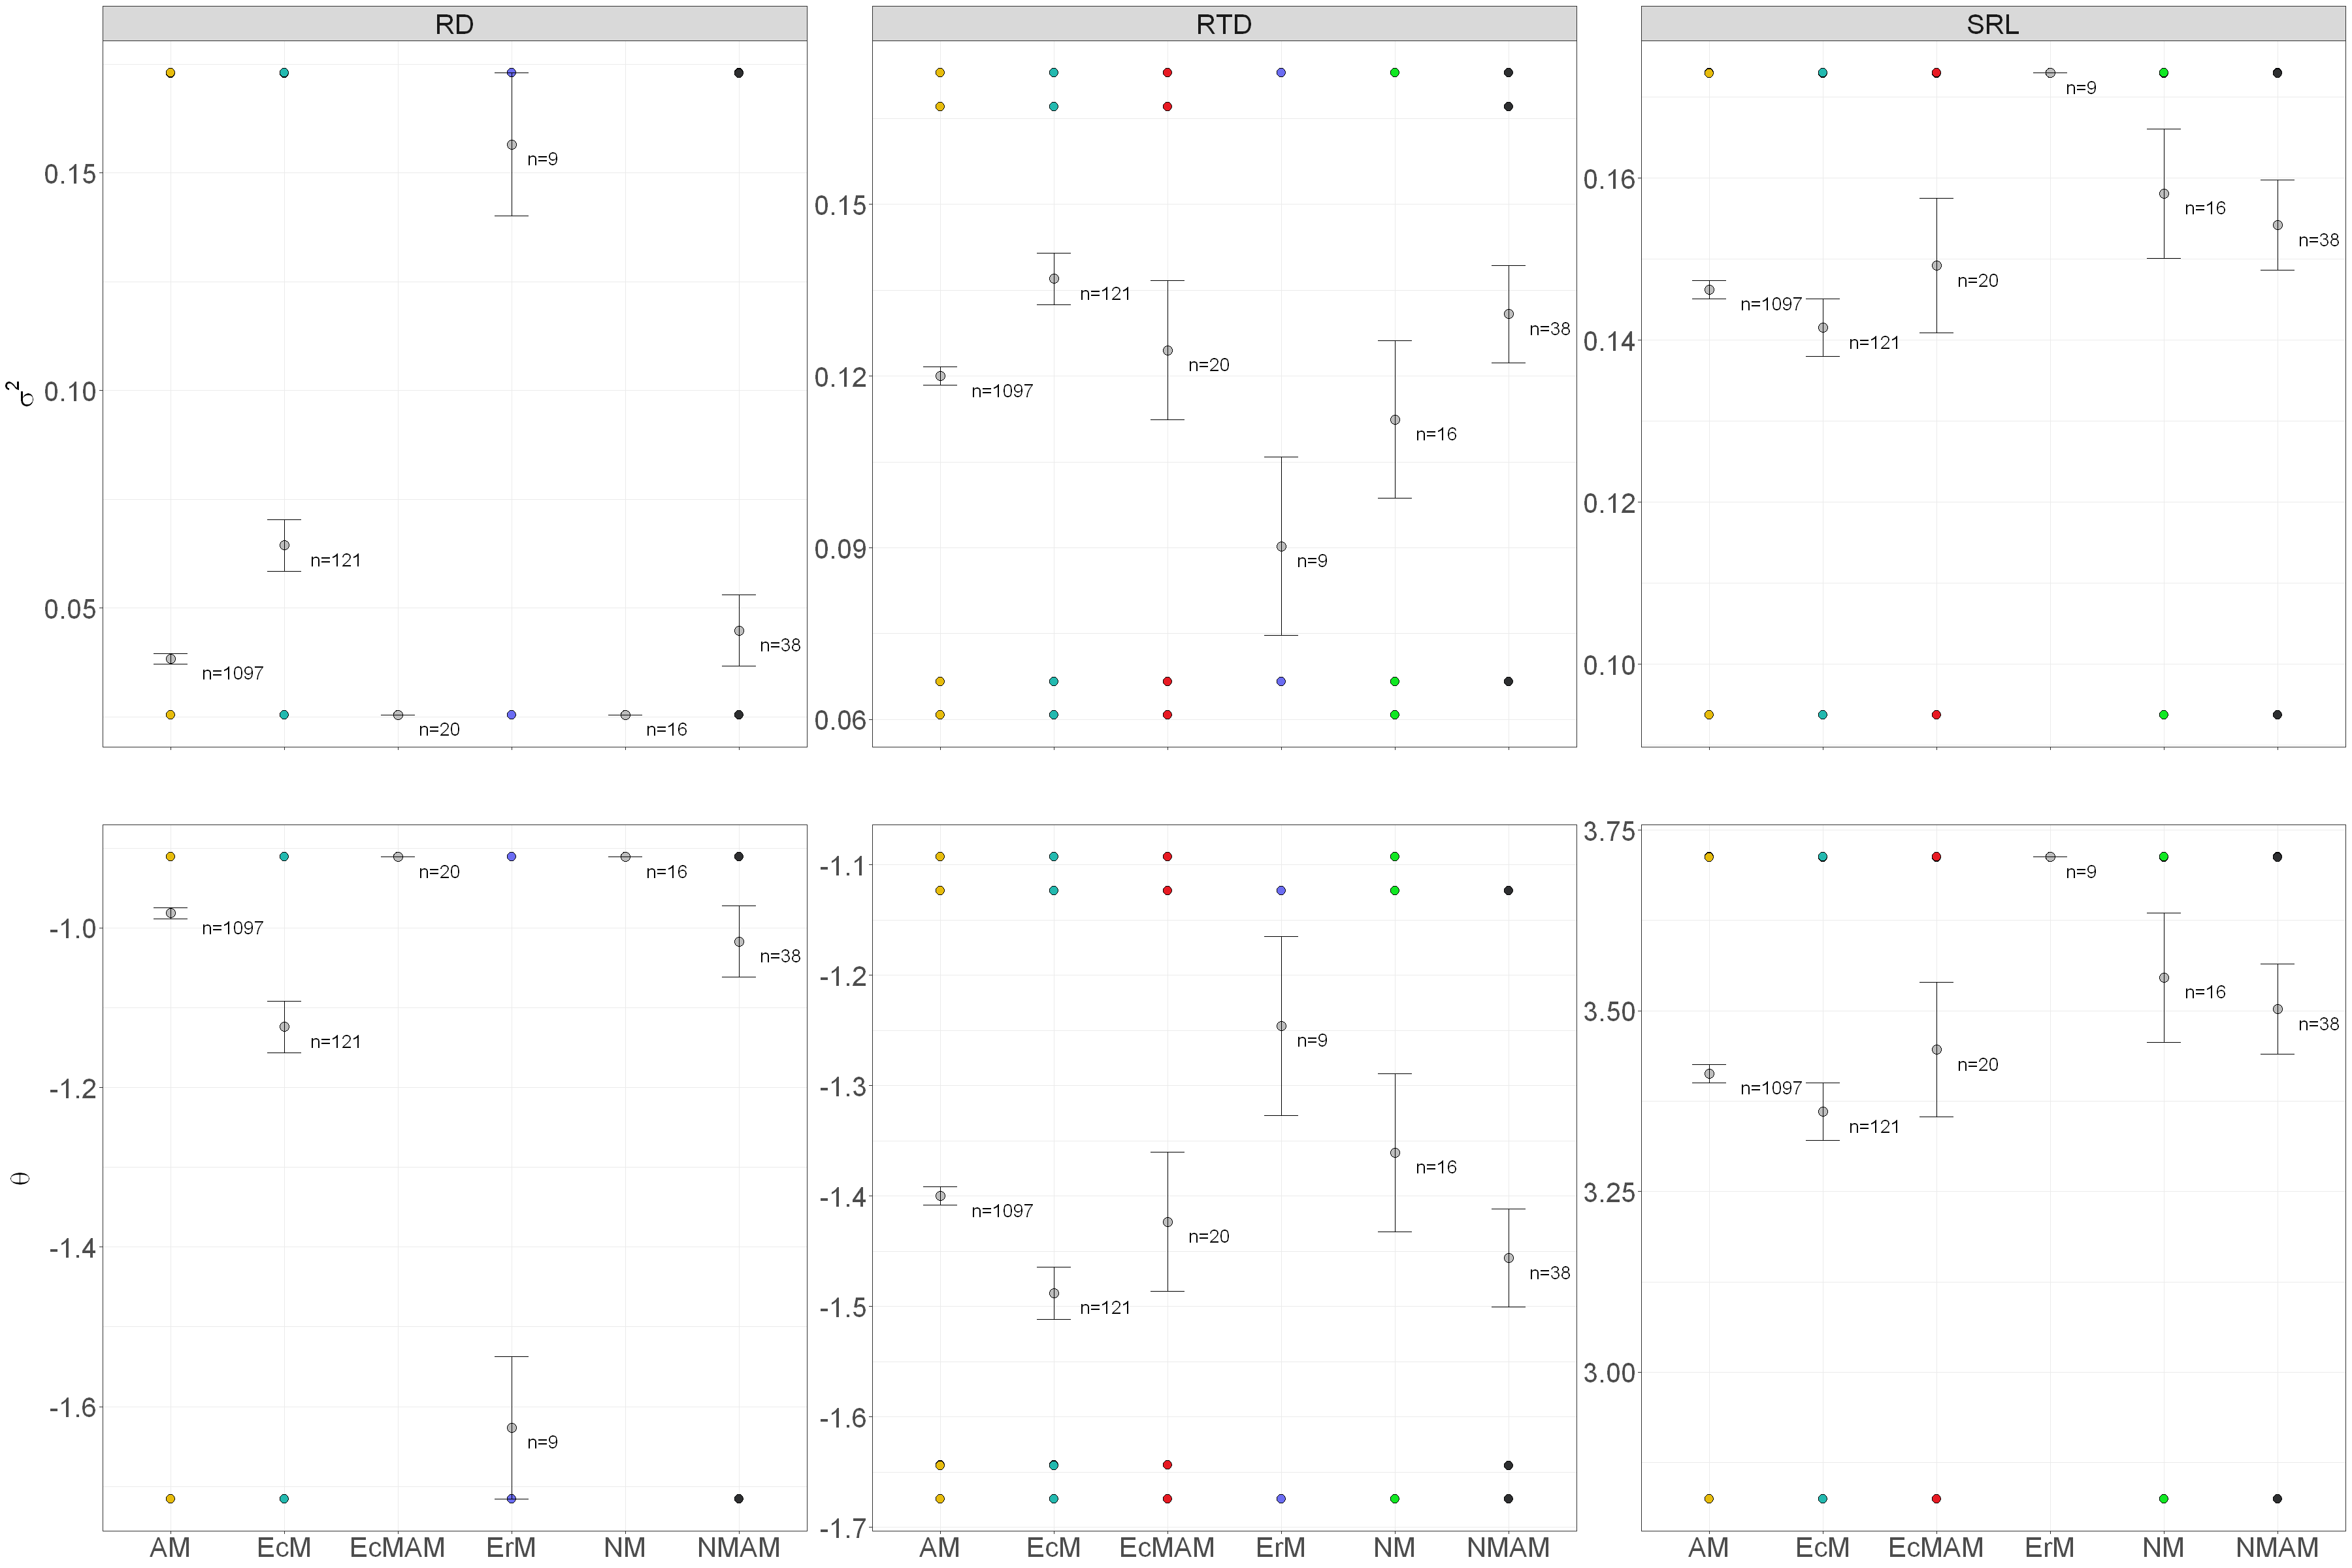

In [42]:
options(repr.plot.width = 30, repr.plot.height = 20)
# https://rpkgs.datanovia.com/ggpubr/reference/ggarrange.html                                                                            
panel <- ggpubr::ggarrange(p1, p2, nrow = 2, align = "hv")#, labels = c("Sigma.sq", "Theta"), hjust = 3, font.label = list(size = 20, color = "black"))
plot(panel)
# ggplot2::ggsave(plot = panel, file = "../../plots/sigmasq_and_theta.png", device = "png", width = 32, height = 20, units = "in", dpi = 800)

In [16]:
# what's strange here is that plots for sigma.sq and theta look like mirror images for RD and RTD?? and identical for SRL???

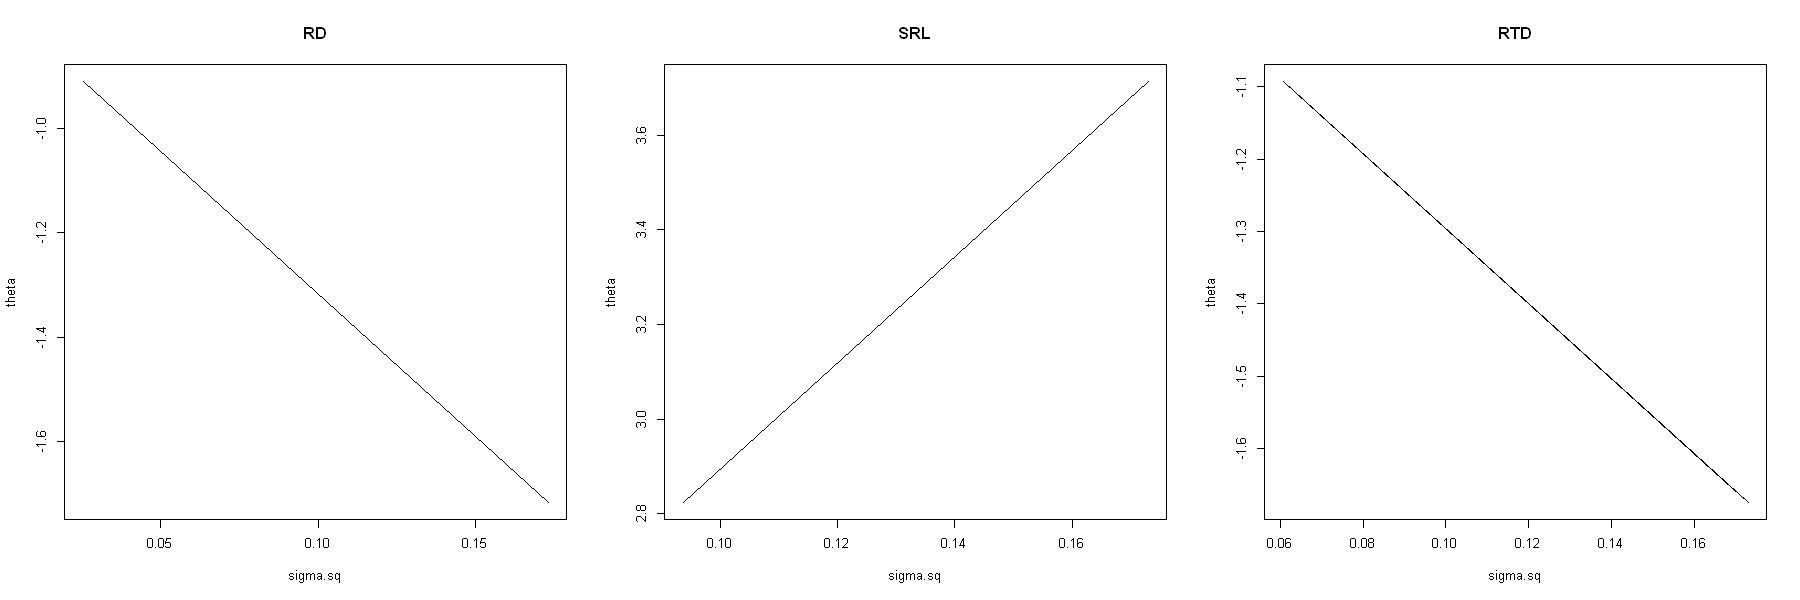

In [41]:
par(mfrow = c(1, 3))
options(repr.plot.width = 15, repr.plot.height = 5)

plot(theta~sigma.sq, data = rd_avgs_cid, type = "l", main = "RD")
plot(theta~sigma.sq, data = srl_avgs_cid, type = "l", main = "SRL")
plot(theta~sigma.sq, data = rtd_avgs_cid, type = "l", main = "RTD")

## ___Supplementary materials___
------------------------

In [37]:
options(repr.plot.width = 30, repr.plot.height = 30)

# subset the CID averages and group by the trait, do the calculations

#-----------
# sigma.sq
#-----------

summarytable <- split.data.frame(subset(df, cd == FALSE), ~trait) |> lapply(FUN = function(d) data.frame(
    tip.state = aggregate(sigma.sq ~ tip_state, data = d, FUN = mean)$tip_state,
    n = aggregate(sigma.sq ~ tip_state, data = d, FUN = length)$sigma.sq,
    m = aggregate(sigma.sq ~ tip_state, data = d, FUN = mean)$sigma.sq,
    err = aggregate(sigma.sq ~ tip_state, data = d, FUN = function(s) { sd(s) / sqrt(length(s)) })$sigma.sq
))

summarytable <- rbind(cbind(summarytable$RD, trait = "RD"), cbind(summarytable$SRL, trait = "SRL"), cbind(summarytable$RTD, trait = "RTD"))

p1 <- ggplot(aes(x = tip_state, y = sigma.sq, fill = I(col)), data = subset(df, cd == FALSE)) +
      geom_point(pch = 21, show.legend = FALSE, size = 3.5) + # https://stackoverflow.com/questions/61112846/ggplot-how-to-make-color-inside-aes-takes-in-parameter-as-a-hex-code-for-color
      stat_summary(fun = "mean", geom = "point", size = 4, fill = "grey", colour = "black", pch = 21) +
      geom_errorbar(aes(ymin = m - err, ymax = m + err, x = tip.state, y = m), data = summarytable, inherit.aes = FALSE, width = 0.3) +
      geom_text(aes(y = m, x = tip.state, label = paste0("n=", n)), hjust = -0.5, vjust = 1.5, data = summarytable, inherit.aes = FALSE, size = 6) +
      theme_bw() +
      xlab(NULL) +
      ylab(expression(sigma^2)) +
      # scale_x_discrete(expand = expansion(mult = c(0, 0.15))) + # https://stackoverflow.com/questions/76613337/how-to-avoid-cropping-of-labels-in-ggarrange
      theme(axis.title.y = element_text(size = 25, vjust = 2.25),
            axis.text = element_text(size = 25), axis.text.x = element_blank(), # don't show the x tick labels
            strip.text = element_text(size=25)) + # strip.text for the facet wrap grid titles
      facet_wrap(~trait, scales = "free")

#--------
# alpha
#--------
                                                                            
summarytable <- split.data.frame(subset(df, cd == FALSE), ~trait) |> lapply(FUN = function(d) data.frame(
    tip.state = aggregate(alpha ~ tip_state, data = d, FUN = mean)$tip_state,
    n = aggregate(alpha ~ tip_state, data = d, FUN = length)$alpha,
    m = aggregate(alpha ~ tip_state, data = d, FUN = mean)$alpha,
    err = aggregate(alpha ~ tip_state, data = d, FUN = function(s) { sd(s) / sqrt(length(s)) })$alpha
))

summarytable <- rbind(cbind(summarytable$RD, trait = "RD"), cbind(summarytable$SRL, trait = "SRL"), cbind(summarytable$RTD, trait = "RTD"))

p2 <- ggplot(aes(x = tip_state, y = alpha, fill = I(col)), data = subset(df, cd == FALSE)) +
      geom_point(pch = 21, show.legend = FALSE, size = 3.5) + # https://stackoverflow.com/questions/61112846/ggplot-how-to-make-color-inside-aes-takes-in-parameter-as-a-hex-code-for-color
      stat_summary(fun = "mean", geom = "point", size = 4, fill = "grey", colour = "black", pch = 21) +
      geom_errorbar(aes(ymin = m - err, ymax = m + err, x = tip.state, y = m), data = summarytable, inherit.aes = FALSE, width = 0.3) +
      geom_text(aes(y = m, x = tip.state, label = paste0("n=", n)), hjust = -0.5, vjust = 1.5, data = summarytable, inherit.aes = FALSE, size = 6) +
      theme_bw() +
      xlab(NULL) +
      ylab(expression(alpha)) +
      # scale_x_discrete(expand = expansion(mult = c(0, 0.15))) +
      theme(axis.title.y = element_text(size = 22.5, vjust = 2.25),
            axis.text = element_text(size = 25), axis.text.x = element_blank(), # don't show the x tick labels
            strip.background = element_blank(), # no strip labels
            strip.text.x = element_blank()) +  # no strip texts
      facet_wrap(~trait, scales = "free")

#--------
# theta
#--------
                                                                            
summarytable <- split.data.frame(subset(df, cd == FALSE), ~trait) |> lapply(FUN = function(d) data.frame(
    tip.state = aggregate(theta ~ tip_state, data = d, FUN = mean)$tip_state,
    n = aggregate(theta ~ tip_state, data = d, FUN = length)$theta,
    m = aggregate(theta ~ tip_state, data = d, FUN = mean)$theta,
    err = aggregate(theta ~ tip_state, data = d, FUN = function(s) { sd(s) / sqrt(length(s)) })$theta
))

summarytable <- rbind(cbind(summarytable$RD, trait = "RD"), cbind(summarytable$SRL, trait = "SRL"), cbind(summarytable$RTD, trait = "RTD"))
 
p3 <- ggplot(aes(x = tip_state, y = theta, fill = I(col)), data = subset(df, cd == FALSE)) +
      geom_point(pch = 21, show.legend = FALSE, size = 3.5) + # https://stackoverflow.com/questions/61112846/ggplot-how-to-make-color-inside-aes-takes-in-parameter-as-a-hex-code-for-color
      stat_summary(fun = "mean", geom = "point", size = 4, fill = "grey", colour = "black", pch = 21) +
      geom_errorbar(aes(ymin = m - err, ymax = m + err, x = tip.state, y = m), data = summarytable, inherit.aes = FALSE, width = 0.3) +
      geom_text(aes(y = m, x = tip.state, label = paste0("n=", n)), hjust = -0.5, vjust = 1.5, data = summarytable, inherit.aes = FALSE, size = 6) +
      theme_bw() +
      xlab(NULL) +
      ylab(expression(theta)) +
      # scale_x_discrete(expand = expansion(mult = c(0, 0.15))) +
      theme(axis.title.y = element_text(size = 22.5, vjust = 2.25),
            axis.text = element_text(size = 25),
            strip.background = element_blank(), # no strip labels
            strip.text.x = element_blank()) +  # no strip texts
      facet_wrap(~trait, scales = "free")

plotgrid <- ggpubr::ggarrange(p1, p2, p3, nrow = 3, align = "hv", labels = c("Sigma.sq", "Alpha", "Theta"),
                             font.label = list(size = 20, color = "black")) # https://github.com/kassambara/ggpubr/issues/38

# plot(plotgrid)
ggplot2::ggsave(plot = plotgrid, file = "../../plots/houwie-cid-supp.png", device = "png", width = 34, height = 32, units = "in", dpi = 600)

In [38]:
options(repr.plot.width = 30, repr.plot.height = 30)

# subset the CD averages and group by the trait, do the calculations

#----------
# sigma.sq
#----------

summarytable <- split.data.frame(subset(df, cd == TRUE), ~trait) |> lapply(FUN = function(d) data.frame(
    tip.state = aggregate(sigma.sq ~ tip_state, data = d, FUN = mean)$tip_state,
    n = aggregate(sigma.sq ~ tip_state, data = d, FUN = length)$sigma.sq,
    m = aggregate(sigma.sq ~ tip_state, data = d, FUN = mean)$sigma.sq,
    err = aggregate(sigma.sq ~ tip_state, data = d, FUN = function(s) { sd(s) / sqrt(length(s)) })$sigma.sq
))

summarytable <- rbind(cbind(summarytable$RD, trait = "RD"), cbind(summarytable$SRL, trait = "SRL"), cbind(summarytable$RTD, trait = "RTD"))

p1 <- ggplot(aes(x = tip_state, y = sigma.sq, fill = I(col)), data = subset(df, cd == TRUE)) +
      geom_point(pch = 21, show.legend = FALSE, size = 3.5) + # https://stackoverflow.com/questions/61112846/ggplot-how-to-make-color-inside-aes-takes-in-parameter-as-a-hex-code-for-color
      stat_summary(fun = "mean", geom = "point", size = 4, fill = "grey", colour = "black", pch = 21) +
      geom_errorbar(aes(ymin = m - err, ymax = m + err, x = tip.state, y = m), data = summarytable, inherit.aes = FALSE, width = 0.3) +
      geom_text(aes(y = m, x = tip.state, label = paste0("n=", n)), hjust = -0.5, vjust = 1.5, data = summarytable, inherit.aes = FALSE, size = 6) +
      theme_bw() +
      xlab(NULL) +
      ylab(expression(sigma^2)) +
      # scale_x_discrete(expand = expansion(mult = c(0, 0.15))) + # https://stackoverflow.com/questions/76613337/how-to-avoid-cropping-of-labels-in-ggarrange
      theme(axis.title.y = element_text(size = 25, vjust = 2.25),
            axis.text = element_text(size = 25), axis.text.x = element_blank(), # don't show the x tick labels
            strip.text = element_text(size=25)) + # strip.text for the facet wrap grid titles
      facet_wrap(~trait, scales = "free")

#--------
# alpha
#--------
                                                                            
summarytable <- split.data.frame(subset(df, cd == TRUE), ~trait) |> lapply(FUN = function(d) data.frame(
    tip.state = aggregate(alpha ~ tip_state, data = d, FUN = mean)$tip_state,
    n = aggregate(alpha ~ tip_state, data = d, FUN = length)$alpha,
    m = aggregate(alpha ~ tip_state, data = d, FUN = mean)$alpha,
    err = aggregate(alpha ~ tip_state, data = d, FUN = function(s) { sd(s) / sqrt(length(s)) })$alpha
))

summarytable <- rbind(cbind(summarytable$RD, trait = "RD"), cbind(summarytable$SRL, trait = "SRL"), cbind(summarytable$RTD, trait = "RTD"))

p2 <- ggplot(aes(x = tip_state, y = alpha, fill = I(col)), data = subset(df, cd == TRUE)) +
      geom_point(pch = 21, show.legend = FALSE, size = 3.5) + # https://stackoverflow.com/questions/61112846/ggplot-how-to-make-color-inside-aes-takes-in-parameter-as-a-hex-code-for-color
      stat_summary(fun = "mean", geom = "point", size = 4, fill = "grey", colour = "black", pch = 21) +
      geom_errorbar(aes(ymin = m - err, ymax = m + err, x = tip.state, y = m), data = summarytable, inherit.aes = FALSE, width = 0.3) +
      geom_text(aes(y = m, x = tip.state, label = paste0("n=", n)), hjust = -0.5, vjust = 1.5, data = summarytable, inherit.aes = FALSE, size = 6) +
      theme_bw() +
      xlab(NULL) +
      ylab(expression(alpha)) +
      # scale_x_discrete(expand = expansion(mult = c(0, 0.15))) +
      theme(axis.title.y = element_text(size = 22.5, vjust = 2.25),
            axis.text = element_text(size = 25), axis.text.x = element_blank(), # don't show the x tick labels
            strip.background = element_blank(), # no strip labels
            strip.text.x = element_blank()) +  # no strip texts
      facet_wrap(~trait, scales = "free")

#--------
# theta
#--------
                                                                            
summarytable <- split.data.frame(subset(df, cd == TRUE), ~trait) |> lapply(FUN = function(d) data.frame(
    tip.state = aggregate(theta ~ tip_state, data = d, FUN = mean)$tip_state,
    n = aggregate(theta ~ tip_state, data = d, FUN = length)$theta,
    m = aggregate(theta ~ tip_state, data = d, FUN = mean)$theta,
    err = aggregate(theta ~ tip_state, data = d, FUN = function(s) { sd(s) / sqrt(length(s)) })$theta
))

summarytable <- rbind(cbind(summarytable$RD, trait = "RD"), cbind(summarytable$SRL, trait = "SRL"), cbind(summarytable$RTD, trait = "RTD"))
 
p3 <- ggplot(aes(x = tip_state, y = theta, fill = I(col)), data = subset(df, cd == TRUE)) +
      geom_point(pch = 21, show.legend = FALSE, size = 3.5) + # https://stackoverflow.com/questions/61112846/ggplot-how-to-make-color-inside-aes-takes-in-parameter-as-a-hex-code-for-color
      stat_summary(fun = "mean", geom = "point", size = 4, fill = "grey", colour = "black", pch = 21) +
      geom_errorbar(aes(ymin = m - err, ymax = m + err, x = tip.state, y = m), data = summarytable, inherit.aes = FALSE, width = 0.3) +
      geom_text(aes(y = m, x = tip.state, label = paste0("n=", n)), hjust = -0.5, vjust = 1.5, data = summarytable, inherit.aes = FALSE, size = 6) +
      theme_bw() +
      xlab(NULL) +
      ylab(expression(theta)) +
      # scale_x_discrete(expand = expansion(mult = c(0, 0.15))) +
      theme(axis.title.y = element_text(size = 22.5, vjust = 2.25),
            axis.text = element_text(size = 25),
            strip.background = element_blank(), # no strip labels
            strip.text.x = element_blank()) +  # no strip texts
      facet_wrap(~trait, scales = "free")

plotgrid <- ggpubr::ggarrange(p1, p2, p3, nrow = 3, align = "hv", labels = c("Sigma.sq", "Alpha", "Theta"),
                             font.label = list(size = 20, color = "black")) # https://github.com/kassambara/ggpubr/issues/38

# plot(plotgrid)
ggplot2::ggsave(plot = plotgrid, file = "../../plots/houwie-cd-supp.png", device = "png", width = 34, height = 32, units = "in", dpi = 600)

## ___Fine root subset comparison___
--------------------

In [11]:
# root diameter <= 2.00 mm subset
cd_diamater_rd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/houwie-update/fineroots-comp/diameter/", cd = TRUE, strip = "_F00679D_CD_100") # CD fits
cid_diamater_rd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/houwie-update/fineroots-comp/diameter/", cd = FALSE, strip = "_F00679D_CID_100") # CID fits

# root order <= 3 subset
cd_order_rd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/houwie-update/fineroots-comp/order/", cd = TRUE, strip = "_F00679O_CD_100") # CD fits
cid_order_rd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/houwie-update/fineroots-comp/order/", cd = FALSE, strip = "_F00679O_CID_100") # CID fits

In [23]:
# CD fits
cbind(OUwie::getModelTable(cd_diamater_rd, type = "AICc")[c("AICc", "dAICc")], # diameter <= 2.00 mm
            OUwie::getModelTable(cd_order_rd, type = "AICc")[c("AICc", "dAICc")]) # order <= 3

,AICc,dAICc,AICc,dAICc
,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,1038.0283,96.93637,856.8457,75.72744
ARDOUMA,1050.4986,109.40669,870.0075,88.88923
ARDOUMV,1011.0424,69.95050,836.1216,55.00327
ARDOUMVA,1009.9540,68.86202,849.8403,68.72198
EROUM,985.7727,44.68073,802.6007,21.48237
EROUMA,996.4345,55.34259,808.7985,27.68017
EROUMV,941.0919,0.00000,781.1183,0.00000
EROUMVA,951.7157,10.62375,791.5634,10.44516
SYMOUM,1004.4454,63.35351,822.0784,40.96015


In [24]:
# CID fits
cbind(OUwie::getModelTable(cid_diamater_rd, type = "AICc")[c("AICc", "dAICc")], # diameter <= 2.00 mm
            OUwie::getModelTable(cid_order_rd, type = "AICc")[c("AICc", "dAICc")]) # order <= 3

,AICc,dAICc,AICc,dAICc
,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,1148.8078,216.72359,867.9785,189.40619
ARDOUMA,1139.8569,207.77265,923.6136,245.04137
ARDOUMV,1116.4180,184.33373,965.0385,286.46620
ARDOUMVA,1109.1865,177.10221,916.7258,238.15356
EROUM,932.0842,0.00000,678.5723,0.00000
EROUMA,1001.9249,69.84064,832.0039,153.43159
EROUMV,971.3704,39.28617,832.0657,153.49342
EROUMVA,944.4469,12.36265,796.4493,117.87705
SYMOUM,1055.9370,123.85273,880.0600,201.48774


In [31]:
fine <- read.csv("../../data/chapter2/FRED/subsets/fineroot-comparison.csv")[c("F00679O", "F00679D")] 
cor.test(fine$F00679D, fine$F00679O, method = "pearson")


	Pearson's product-moment correlation

data:  fine$F00679D and fine$F00679O
t = 59.49, df = 399, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.9370500 0.9570668
sample estimates:
      cor 
0.9479876 


In [8]:
capture.output(diameter_subset_rd_averages_cd <- OUwie::getModelAvgParams(cd_diamater_rd, type = "AICc", force = FALSE), file = nullfile())
capture.output(diameter_subset_rd_averages_cid <- OUwie::getModelAvgParams(cid_diamater_rd, type = "AICc", force = FALSE), file = nullfile())

capture.output(diameter_subset_ord_averages_cd <- OUwie::getModelAvgParams(cd_order_rd, type = "AICc", force = FALSE), file = nullfile())
capture.output(diameter_subset_ord_averages_cid <- OUwie::getModelAvgParams(cid_order_rd, type = "AICc", force = FALSE), file = nullfile())